In [14]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import statsmodels.tsa.api as smt
import matplotlib.pyplot as plt
from scipy.stats import boxcox

%matplotlib inline

In [5]:
sales_of_company_x = pd.read_csv("monthly-sales-of-company-x-jan-6.csv")
robberies_in_boston = pd.read_csv("monthly-boston-armed-robberies-j.csv")
airlines_passengers = pd.read_csv("international-airline-passengers.csv")
mean_monthly_temp = pd.read_csv("mean-monthly-air-temperature-deg.csv")
dowjones_closing = pd.read_csv("weekly-closings-of-the-dowjones-.csv")
female_births = pd.read_csv("daily-total-female-births-in-cal.csv")

airlines_passengers.columns = ["Month", "Count"]
airlines_passengers = airlines_passengers[:-1]

all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers["Count"],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]}

## Исходные графики всех временных рядов

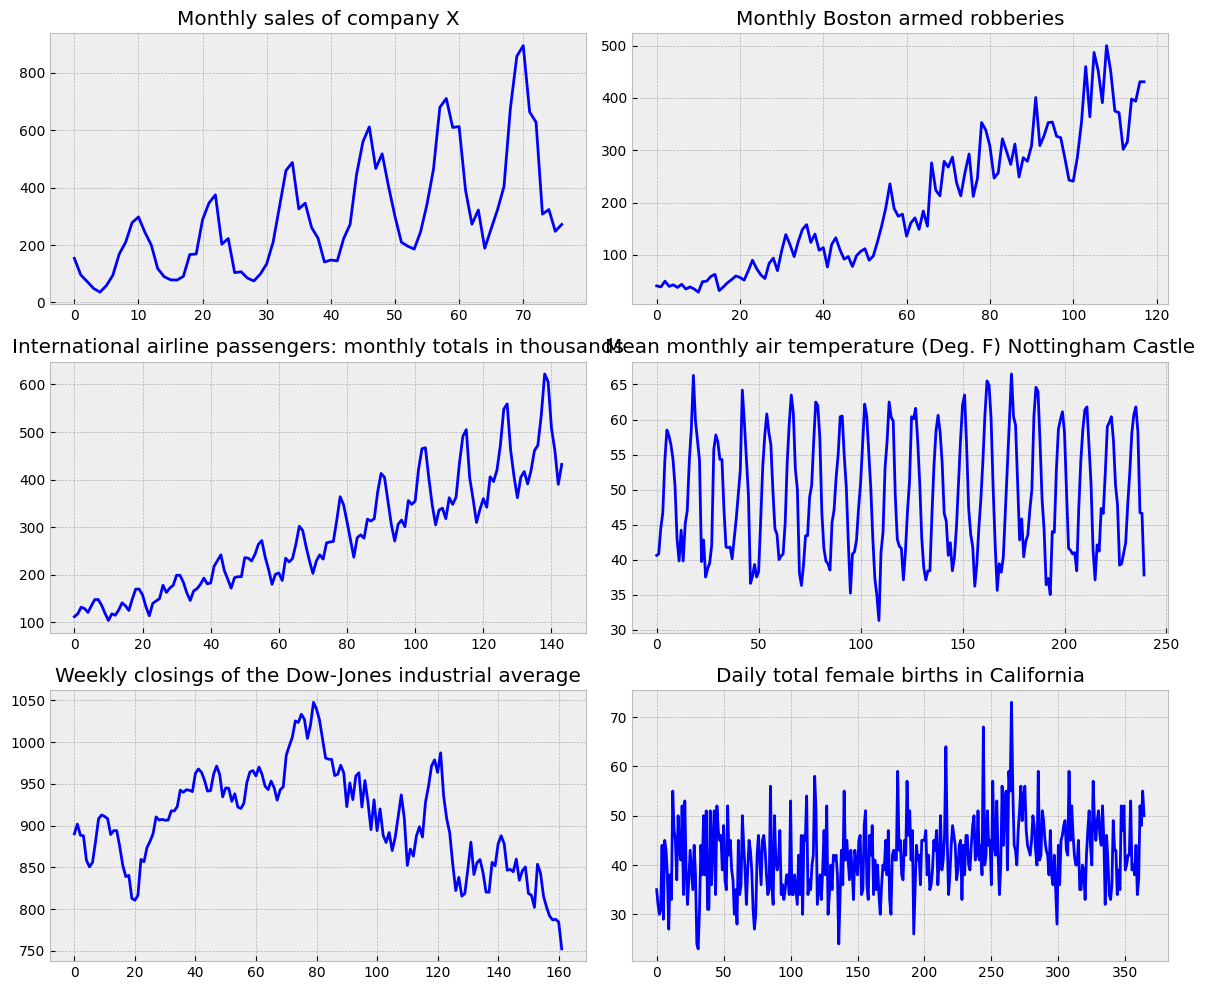

In [9]:
with plt.style.context('bmh'):
    plt.figure(figsize=(12, 10))
    layout = (3, 2)
    for i, key in enumerate(all_series.keys()):
        x = i % 2
        y = int((i - x) / 2)

        ts_ax = plt.subplot2grid(layout, (y, x))
        all_series[key].plot(ax=ts_ax, color='blue')
        ts_ax.set_title(key)

    plt.tight_layout()

в графиках видно:

1 продажи компании X имеют тренд, сезонные колебания и увеличивающийся размах;
2 число вооружённых ограблений в Бостоне имеет выраженный восходящий тренд;
3 число авиапассажиров содержит тренд, сезонность и увеличивающуюся дисперсию;
4 температура имеет сильную годовую сезонность;
5 индекс Dow Jones меняет уровень во времени;
7 число рождений колеблется около относительно постоянного уровня без явного тренда.


Функции из ноутбуков

In [20]:
# Dickey-Fuller

def test_stationarity(timeseries):
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            'Test Statistic',
            'p-value',
            '#Lags Used',
            'Number of Observations Used'])
    for [key, value] in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

In [21]:
def tsplot(y, lags=None, figsize=(14, 8), style='bmh'):
    test_stationarity(y)

    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (4, 1)

        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0))
        pacf_ax = plt.subplot2grid(layout, (3, 0))

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title('Original')

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()

    return

Monthly sales of company X



Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


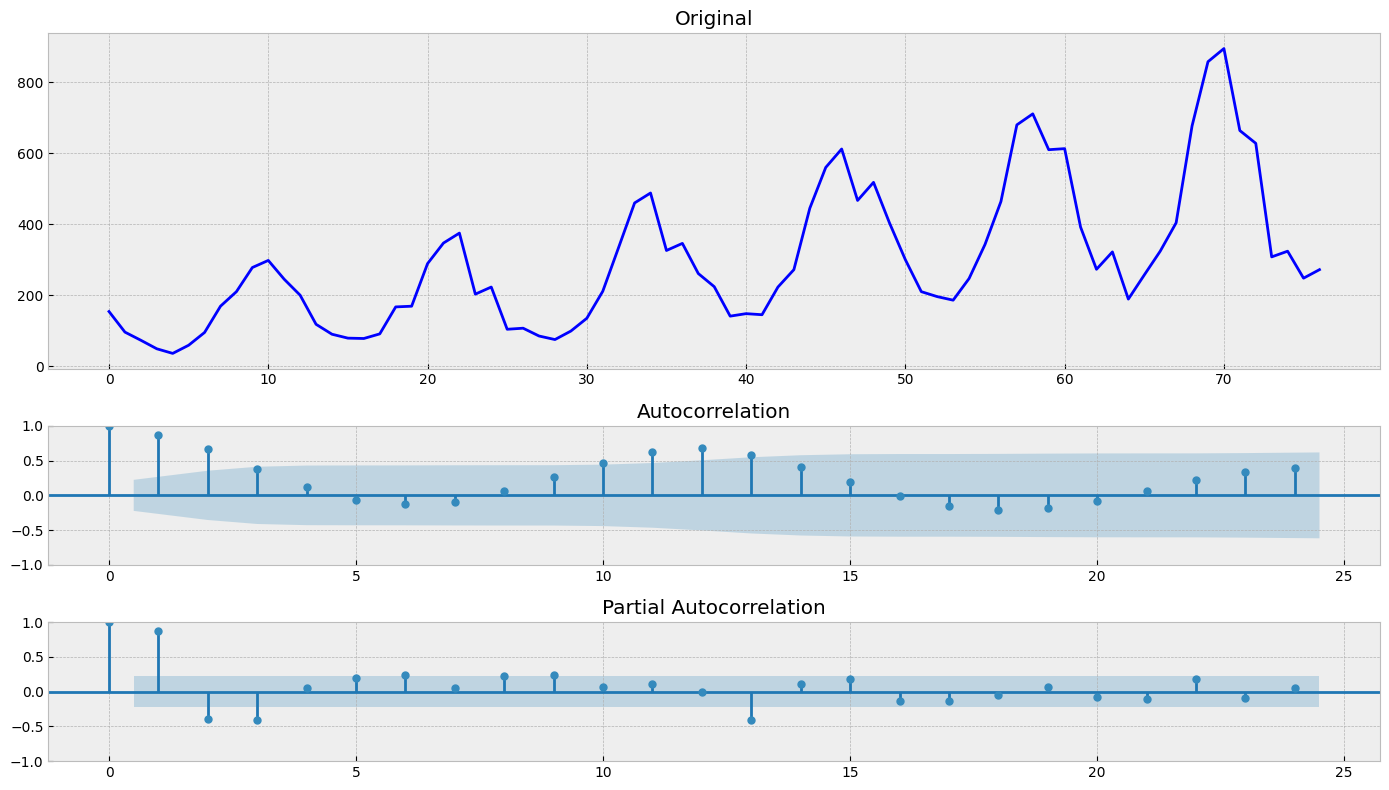

In [22]:
series_sales = all_series["Monthly sales of company X"]
tsplot(series_sales, lags=24)

`p-value` исходного ряда значительно больше 0.05, поэтому гипотезу о нестационарности отвергнуть нельзя.

Так как размах колебаний увеличивается вместе с уровнем, применим преобразование Бокса -Кокса с `lambda = 0`.


Results of Dickey-Fuller Test:
Test Statistic                 -0.908049
p-value                         0.785310
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


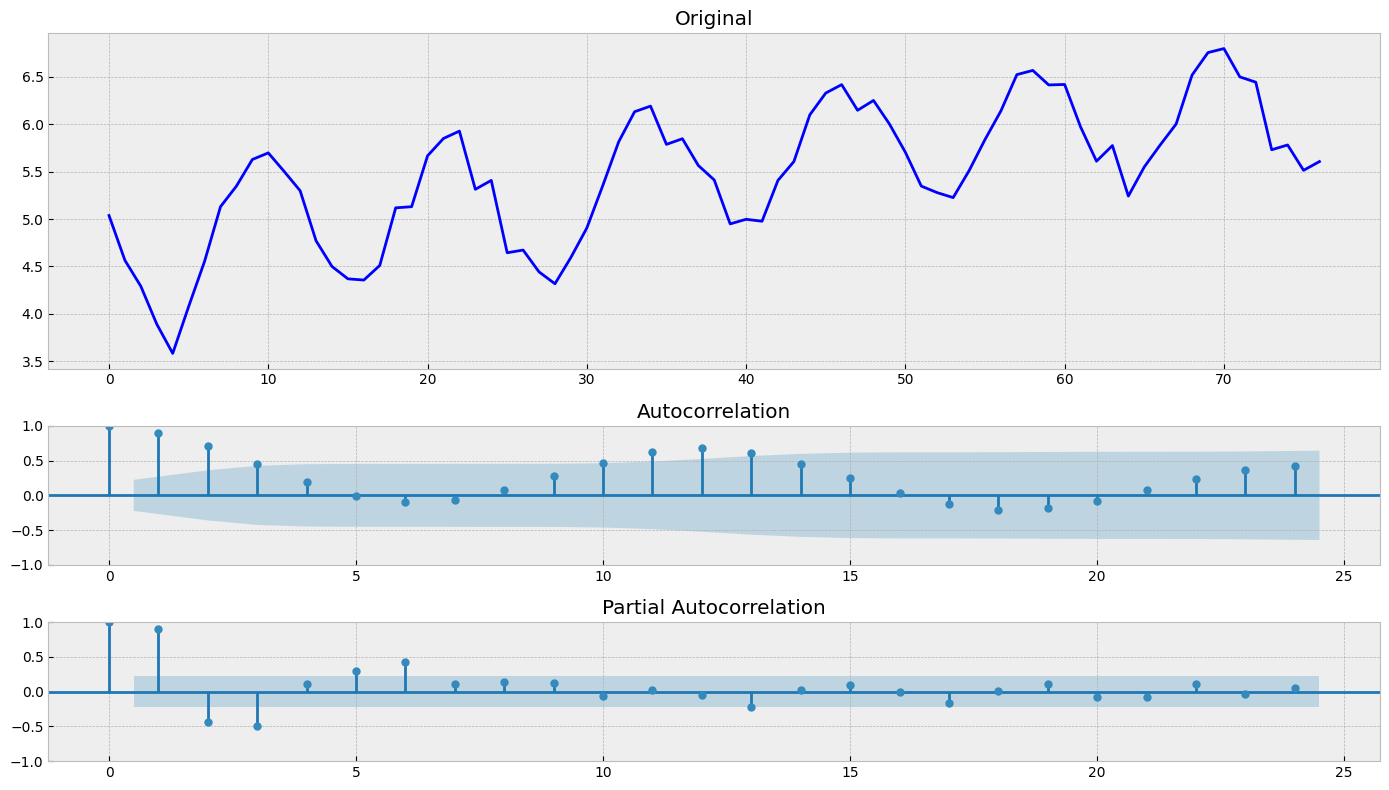

In [23]:
series_sales = boxcox(series_sales, 0)
tsplot(series_sales, lags=24)

Преобразование уменьшило изменение дисперсии, но тренд сохранился. Уберём его первым дифференцированием.


Results of Dickey-Fuller Test:
Test Statistic                 -3.135644
p-value                         0.024025
#Lags Used                     11.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64


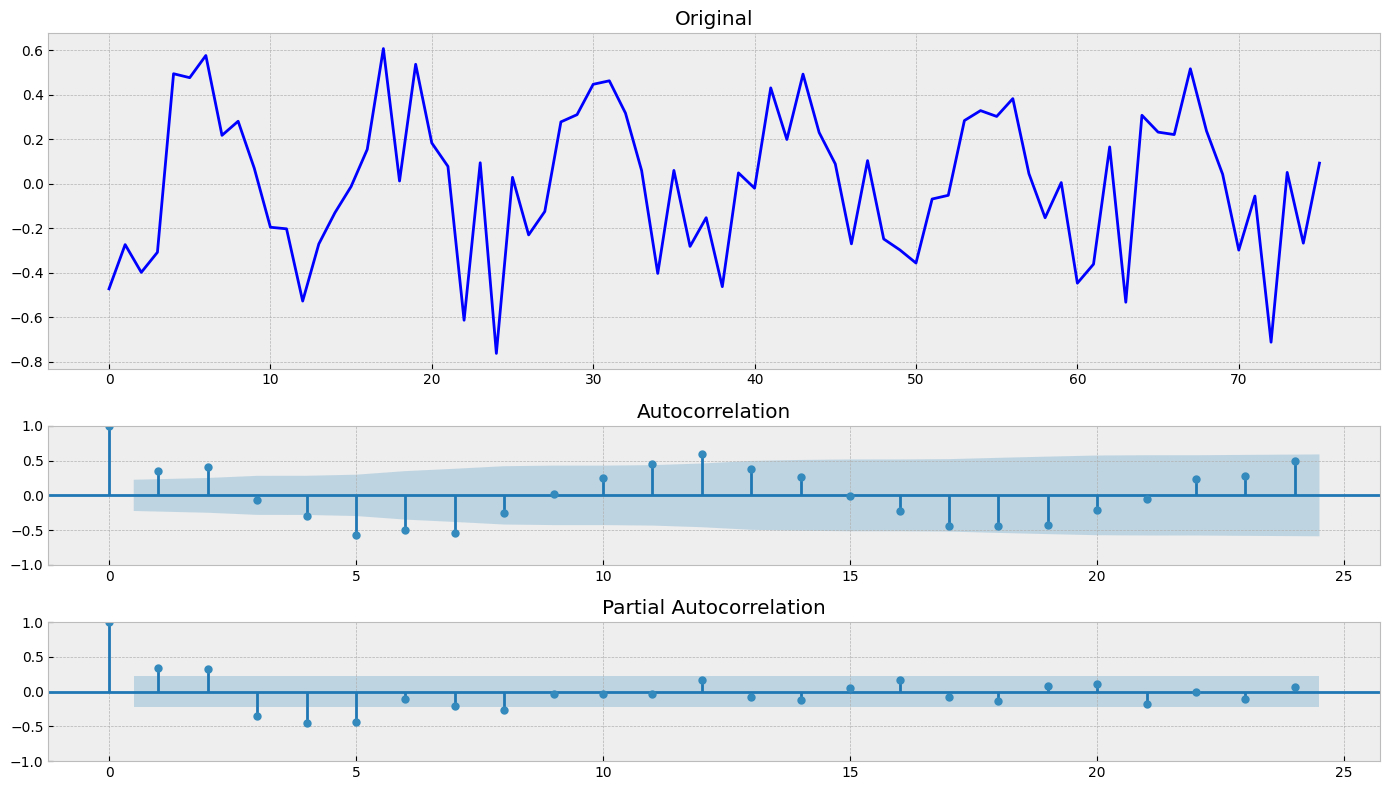

In [24]:
series_sales = series_sales[1:] - series_sales[:-1]
tsplot(series_sales, lags=24)

После первого дифференцирования `p-value` стал меньше 0.05, но на графике и коррелограмме ещё заметна выраженная структура. В лекции указано, что дифференцирование можно применять несколько раз. Выполним второе дифференцирование.


Results of Dickey-Fuller Test:
Test Statistic                -7.101182e+00
p-value                        4.164137e-10
#Lags Used                     1.100000e+01
Number of Observations Used    6.300000e+01
Critical Value (1%)           -3.538695e+00
Critical Value (5%)           -2.908645e+00
Critical Value (10%)          -2.591897e+00
dtype: float64


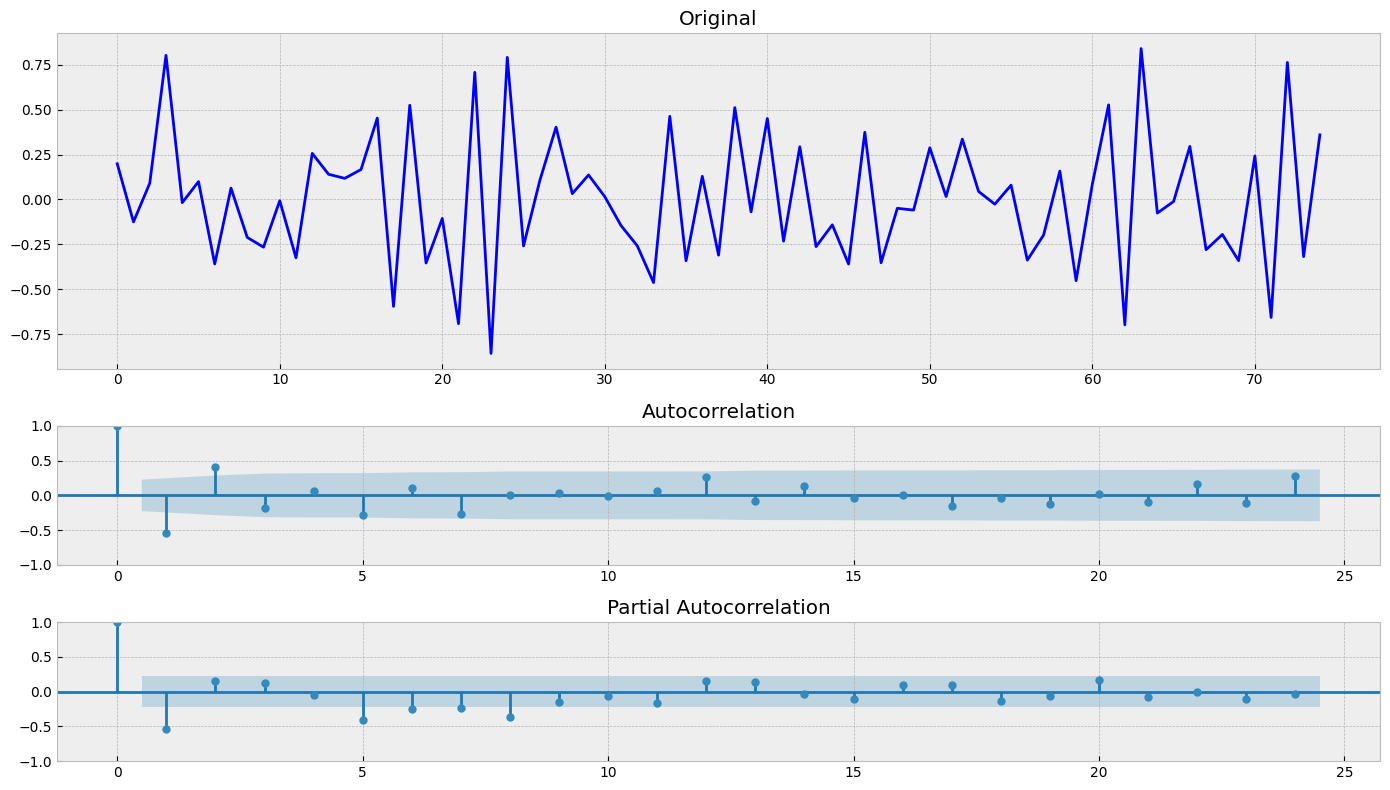

In [25]:
series_sales = series_sales[1:] - series_sales[:-1]
tsplot(series_sales, lags=24)

Вывод: после преобразования Бокса - Кокса и двух последовательных дифференцирований тест Дики - Фуллера уверенно отвергает гипотезу о нестационарности. Средний уровень преобразованного ряда стабилизировался, а автокорреляции быстрее затухают.


2. Monthly Boston armed robberies


Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64


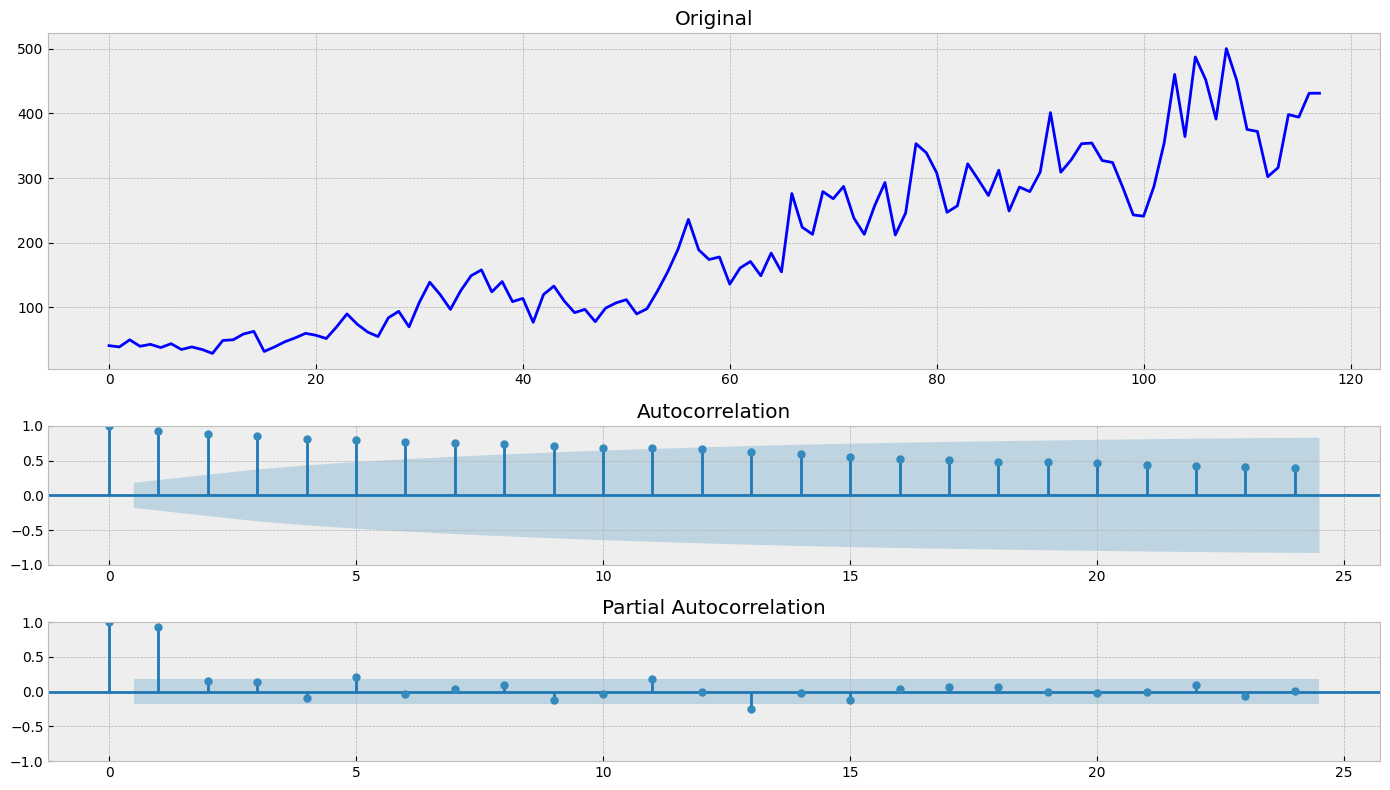

In [26]:
series_robberies = all_series["Monthly Boston armed robberies"]
tsplot(series_robberies, lags=24)

`p-value` исходного ряда значительно больше 0.05. Уберём тренд первым дифференцированием.


Results of Dickey-Fuller Test:
Test Statistic                -7.428564e+00
p-value                        6.450795e-11
#Lags Used                     1.000000e+01
Number of Observations Used    1.060000e+02
Critical Value (1%)           -3.493602e+00
Critical Value (5%)           -2.889217e+00
Critical Value (10%)          -2.581533e+00
dtype: float64


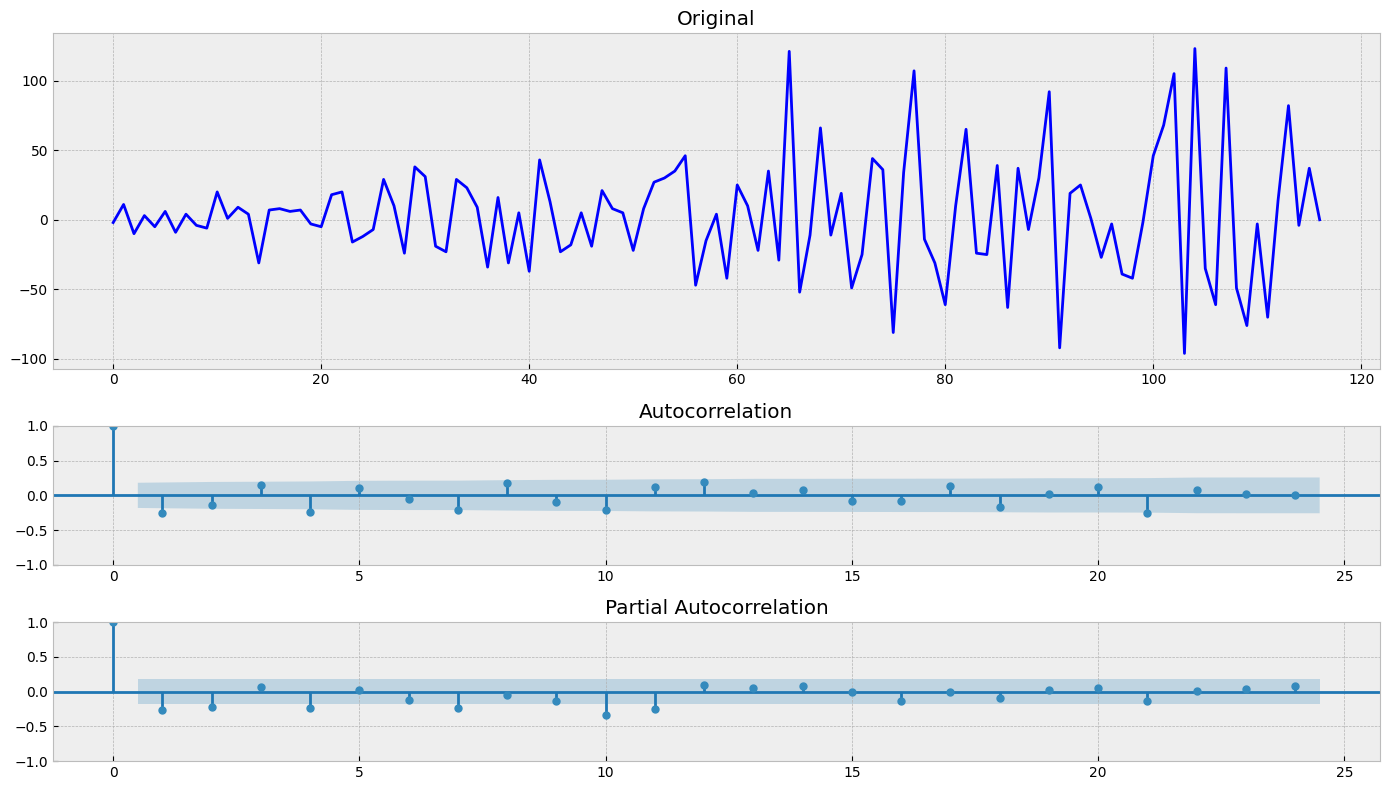

In [27]:
series_robberies = series_robberies[1:].values - series_robberies[:-1].values
tsplot(series_robberies, lags=24)

**Вывод:** после первого дифференцирования `p-value` стал существенно меньше 0.05. На графике больше нет устойчивого восходящего тренда, поэтому преобразованный ряд считаем стационарным.


International airline passengers



Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


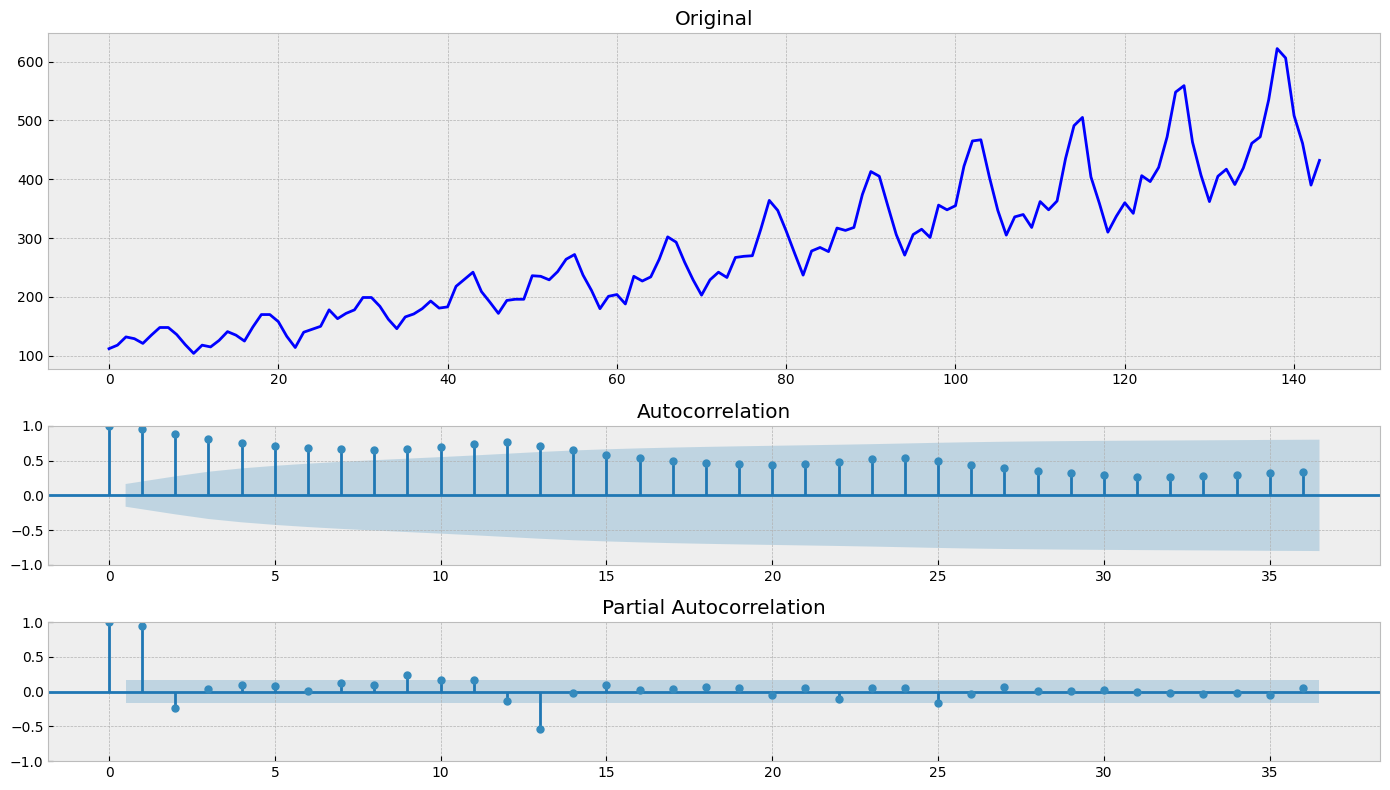

In [28]:
series_airlines = all_series["International airline passengers: monthly totals in thousands"]
tsplot(series_airlines, lags=36)

Исходный ряд нестационарен: присутствуют растущий тренд, годовая сезонность и увеличение размаха. Сначала стабилизируем дисперсию.


Results of Dickey-Fuller Test:
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


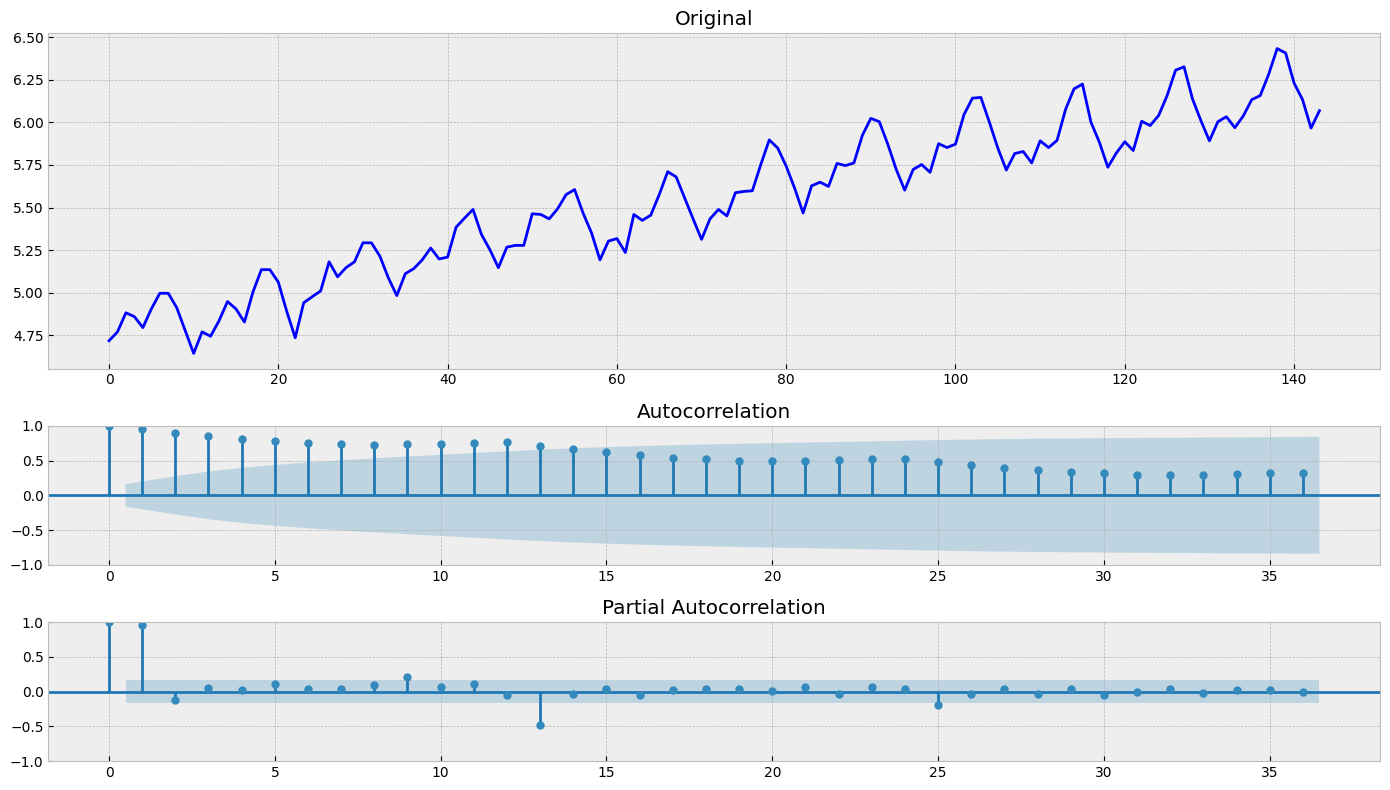

In [29]:
series_airlines = boxcox(series_airlines, 0)
tsplot(series_airlines, lags=36)

Размах стал более стабильным, но тренд сохранился. Применим первое дифференцирование.


Results of Dickey-Fuller Test:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


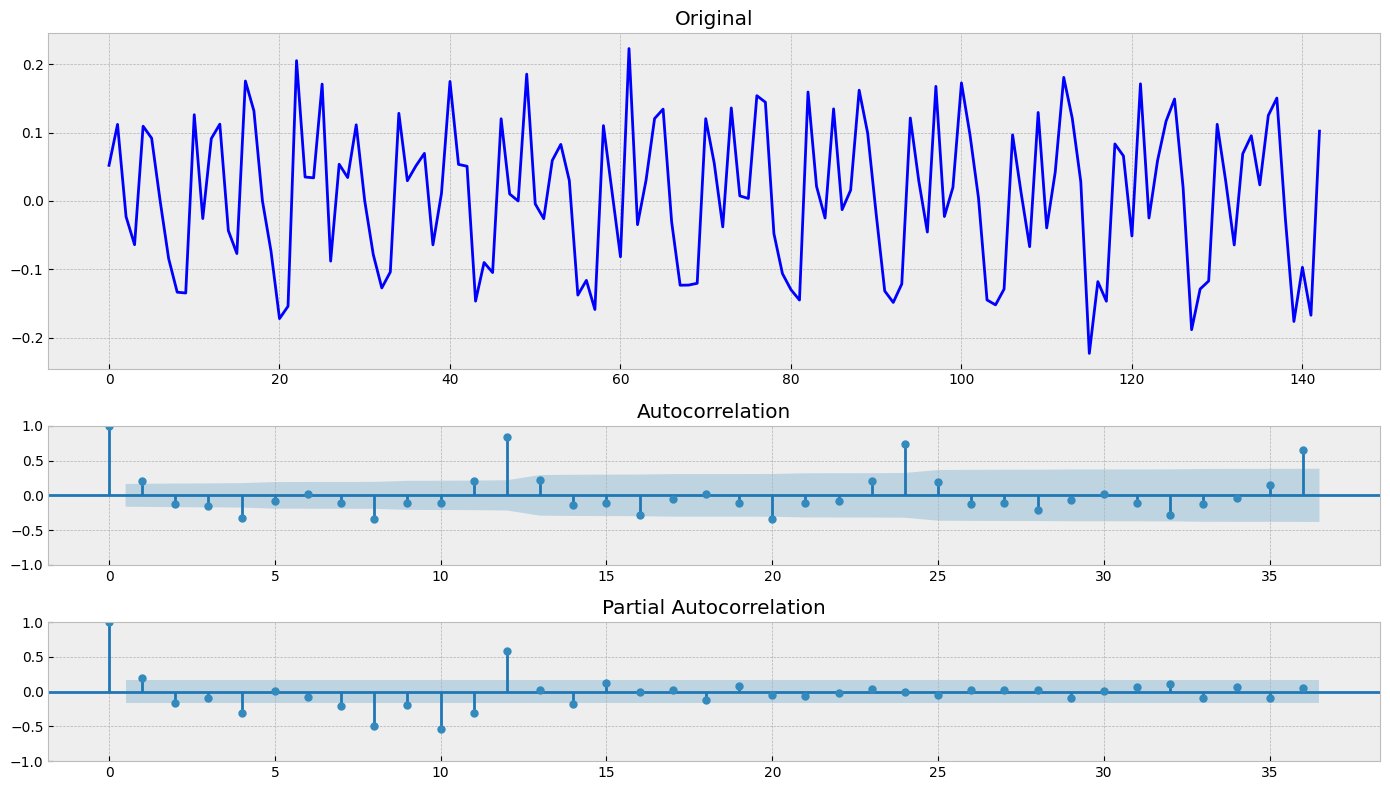

In [30]:
series_airlines = series_airlines[1:] - series_airlines[:-1]
tsplot(series_airlines, lags=36)

После устранения тренда остаётся годовая сезонность: заметны связи на лагах, кратных 12. Выполним сезонное дифференцирование.


Results of Dickey-Fuller Test:
Test Statistic                  -4.443325
p-value                          0.000249
#Lags Used                      12.000000
Number of Observations Used    118.000000
Critical Value (1%)             -3.487022
Critical Value (5%)             -2.886363
Critical Value (10%)            -2.580009
dtype: float64


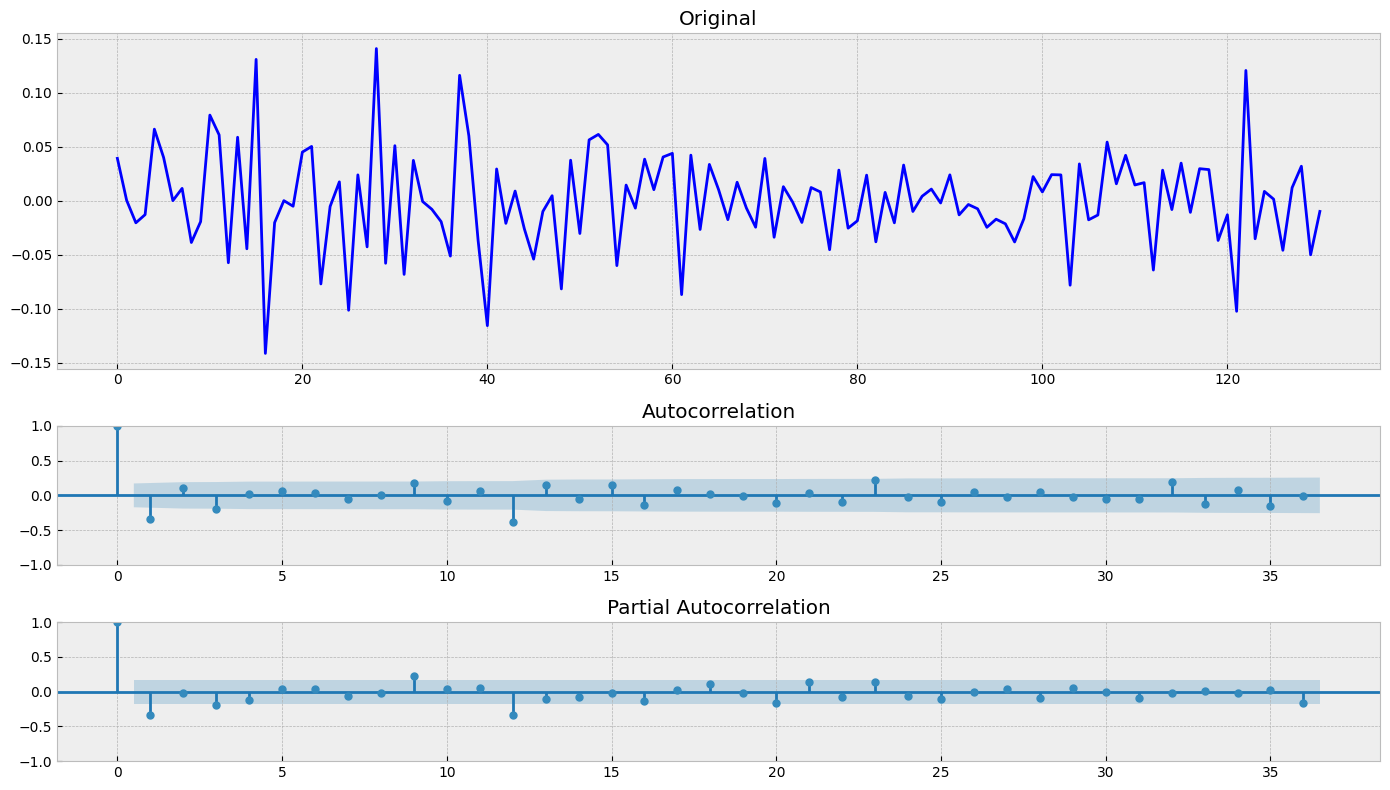

In [31]:
series_airlines = series_airlines[12:] - series_airlines[:-12]
tsplot(series_airlines, lags=36)

**Вывод:** после преобразования Бокса - Кокса, первого и сезонного дифференцирования `p-value` стал меньше 0.05. Тренд и основная годовая сезонность устранены. Ряд считаем стационарным.


4. Mean monthly air temperature



Results of Dickey-Fuller Test:
Test Statistic                  -3.255492
p-value                          0.016989
#Lags Used                      14.000000
Number of Observations Used    225.000000
Critical Value (1%)             -3.459752
Critical Value (5%)             -2.874473
Critical Value (10%)            -2.573663
dtype: float64


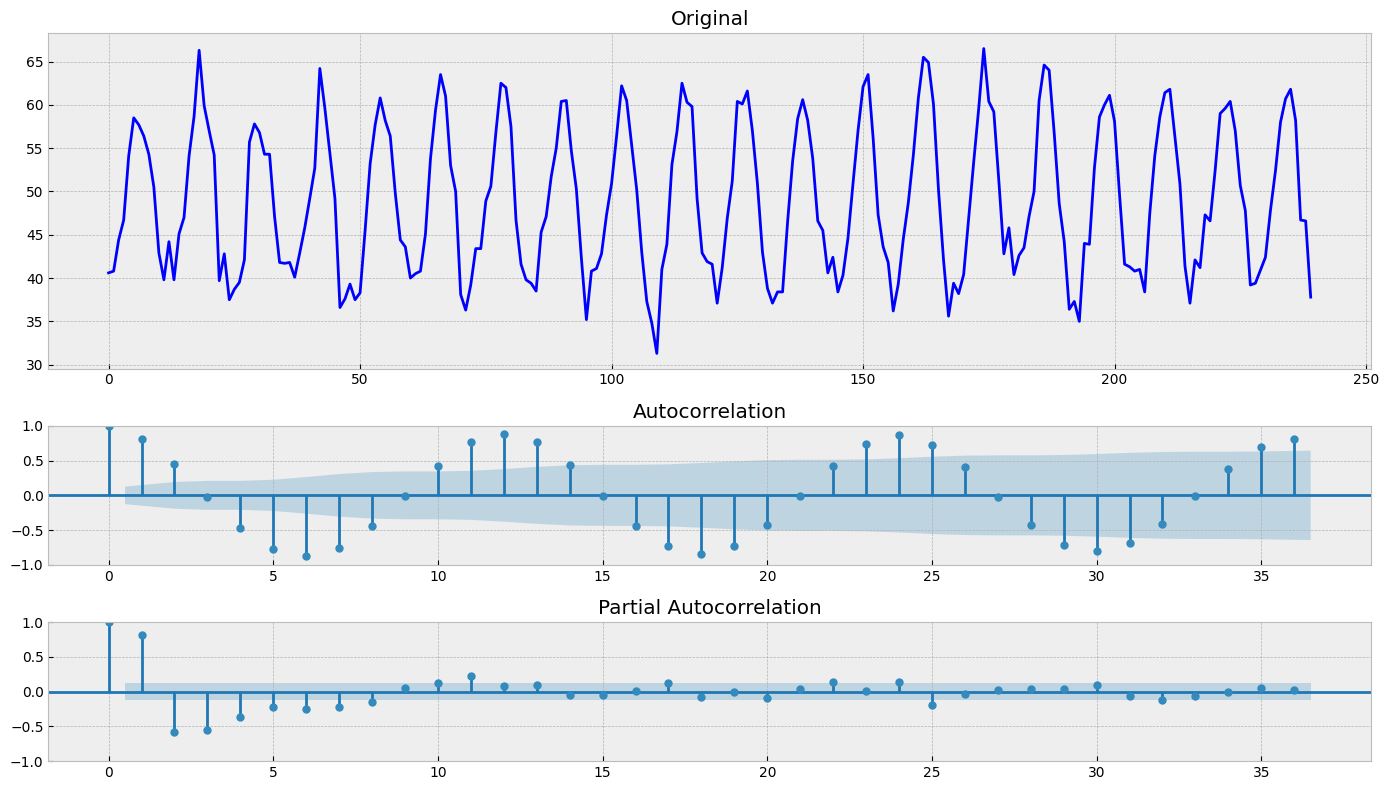

In [36]:
series_temperature = all_series["Mean monthly air temperature (Deg. F) Nottingham Castle"]
tsplot(series_temperature, lags=36)

Тест Дики - Фуллера уже даёт `p-value < 0.05`, но визуальный анализ показывает выраженную повторяющуюся сезонную структуру. В соответствии с рекомендацией лекции комбинируем формальный тест и визуальную проверку. Убираем сезонность разностью с лагом 12.


Results of Dickey-Fuller Test:
Test Statistic                -6.072501e+00
p-value                        1.141945e-07
#Lags Used                     1.200000e+01
Number of Observations Used    2.150000e+02
Critical Value (1%)           -3.461136e+00
Critical Value (5%)           -2.875079e+00
Critical Value (10%)          -2.573986e+00
dtype: float64


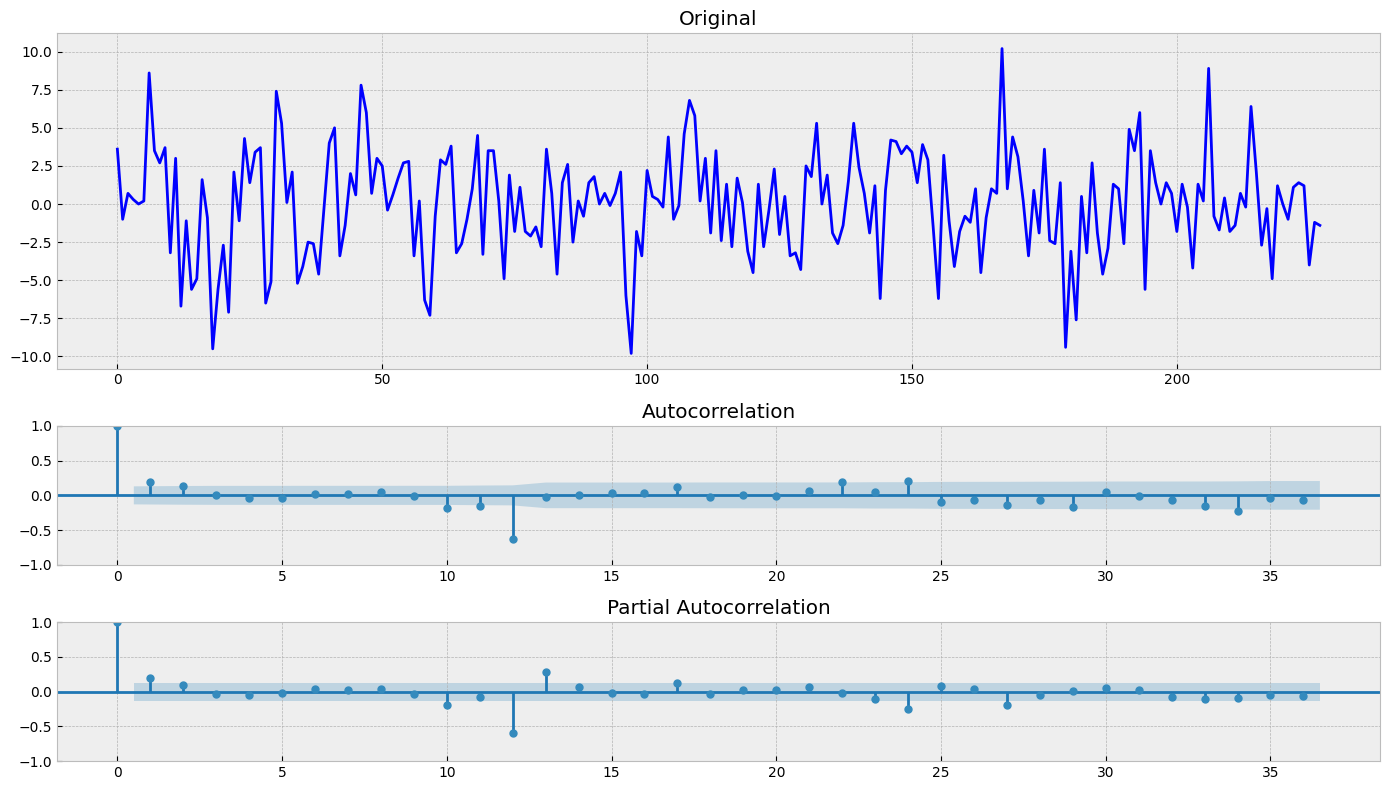

In [37]:
series_temperature = (
    series_temperature[12:].values
    - series_temperature[:-12].values)
tsplot(series_temperature, lags=36)

Вывод: после сезонного дифференцирования годовой повторяющийся уровень устранён, а `p-value` остаётся значительно меньше 0.05. Преобразованный ряд считаем стационарным.


Weekly closings of the Dow Jones



Results of Dickey-Fuller Test:
Test Statistic                  -1.314625
p-value                          0.622455
#Lags Used                       0.000000
Number of Observations Used    161.000000
Critical Value (1%)             -3.471633
Critical Value (5%)             -2.879665
Critical Value (10%)            -2.576434
dtype: float64


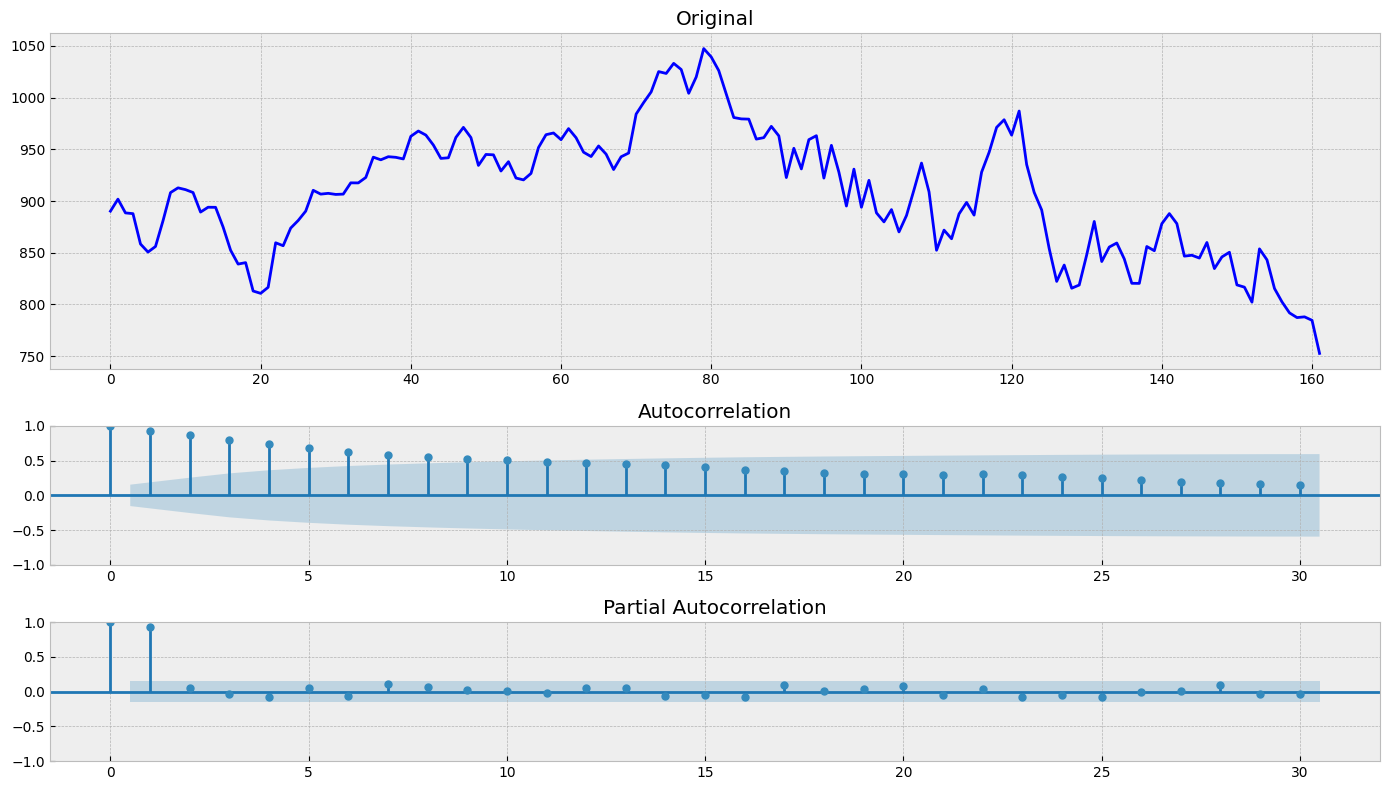

In [42]:
series_dowjones = all_series["Weekly closings of the Dow-Jones industrial average"]
tsplot(series_dowjones, lags=30)

`p-value` исходного ряда больше 0.05. Для устранения изменения уровня выполним первое дифференцирование.


Results of Dickey-Fuller Test:
Test Statistic                -1.302521e+01
p-value                        2.407586e-24
#Lags Used                     0.000000e+00
Number of Observations Used    1.600000e+02
Critical Value (1%)           -3.471896e+00
Critical Value (5%)           -2.879780e+00
Critical Value (10%)          -2.576495e+00
dtype: float64


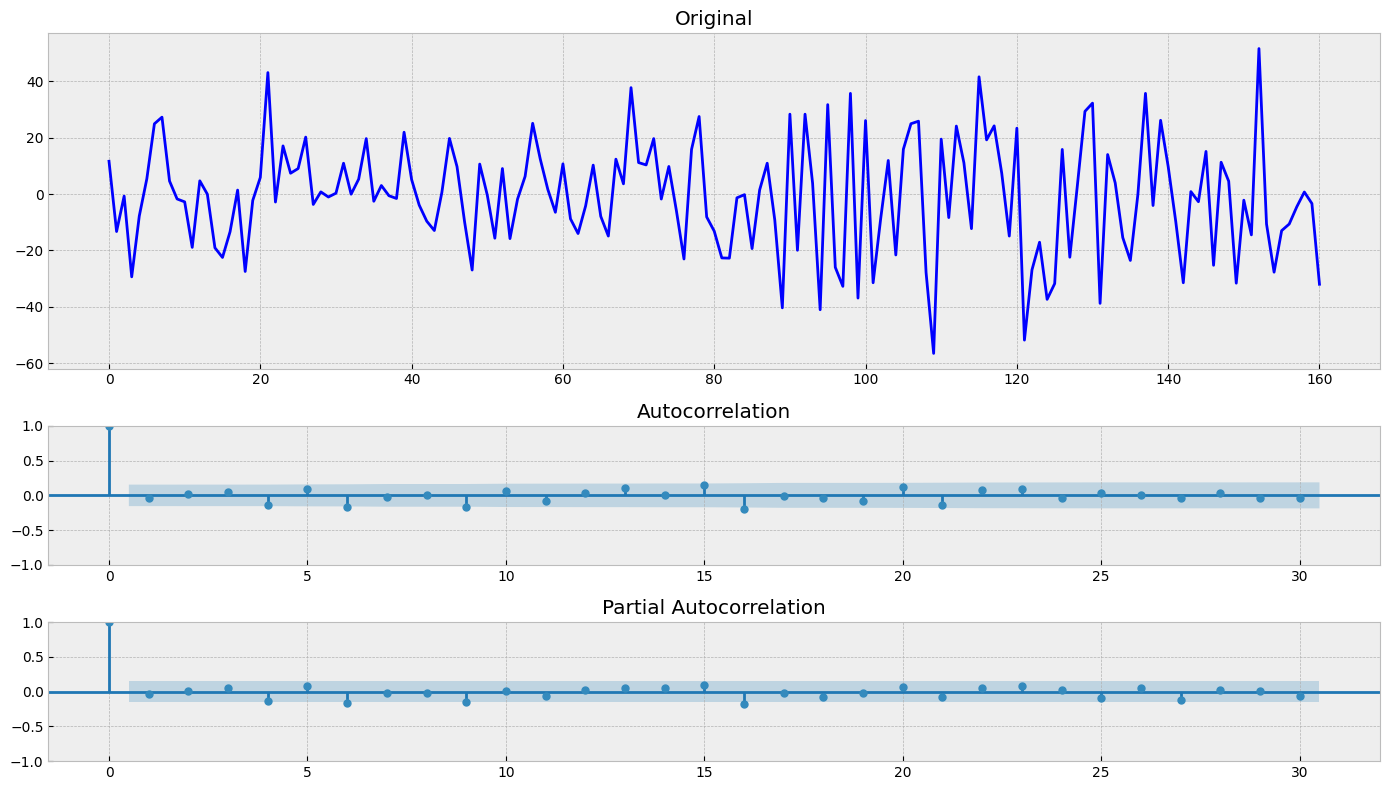

In [43]:
series_dowjones = (series_dowjones[1:].values
    - series_dowjones[:-1].values
)
tsplot(series_dowjones, lags=30)

Вывод: после первого дифференцирования `p-value` стал значительно меньше 0.05, а ряд колеблется около постоянного уровня. Преобразованный ряд считаем стационарным.


6 Daily total female births in California



Results of Dickey-Fuller Test:
Test Statistic                  -4.808291
p-value                          0.000052
#Lags Used                       6.000000
Number of Observations Used    358.000000
Critical Value (1%)             -3.448749
Critical Value (5%)             -2.869647
Critical Value (10%)            -2.571089
dtype: float64


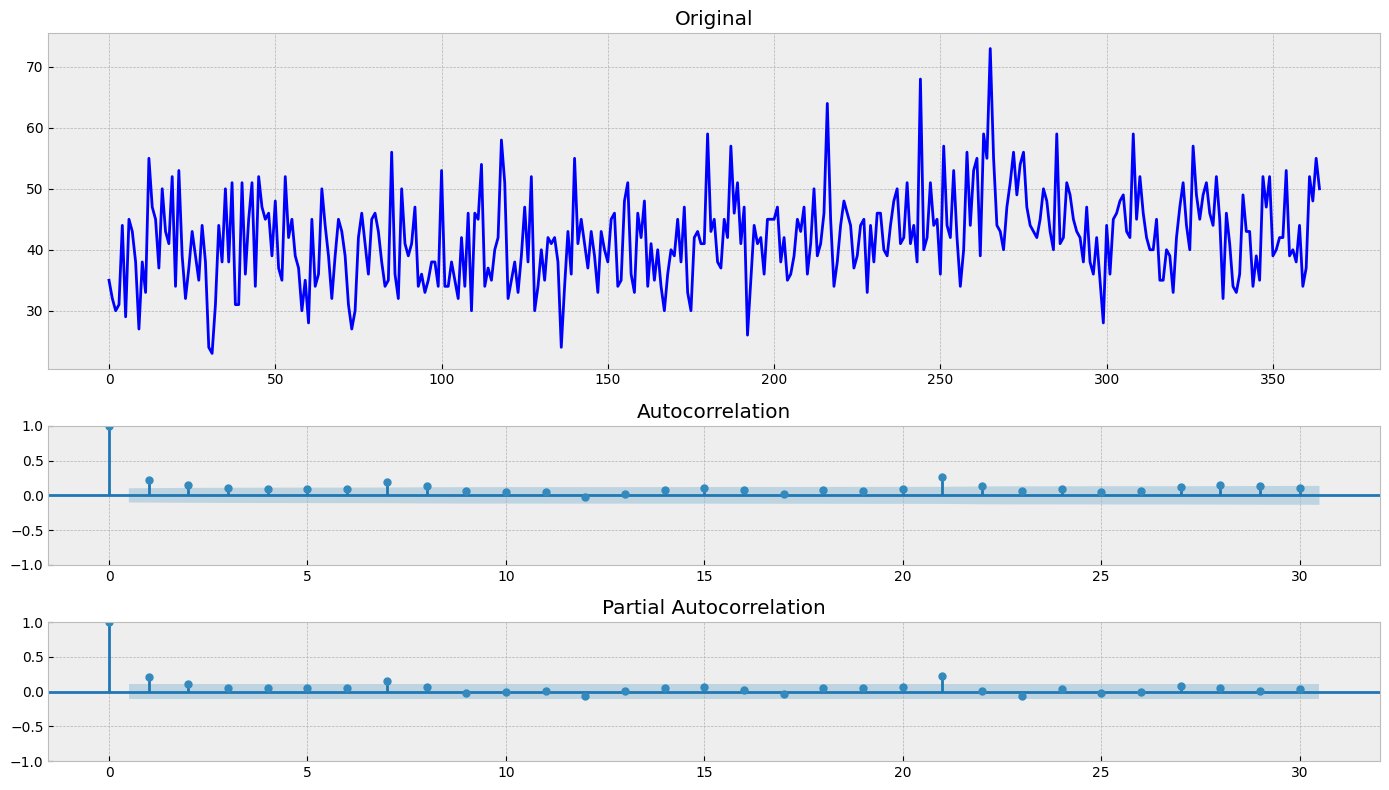

In [44]:
series_births = all_series["Daily total female births in California"]
tsplot(series_births, lags=30)

Вывод: для исходного ряда `p-value <0.05`, а ACF не показывает медленного затухания, характерного для ряда с единичным корнем. Ряд уже является стационарным, поэтому дополнительное преобразование не требуется.


